# Lab 5 — Suplementarny Deep Dive
## Pandas → PySpark: pełna ścieżka od zera do skali

---

> **Dla kogo ten notebook?**
> - Dla tych, którzy **nigdy nie widzieli pandasa** i potrzebują startu od zera
> - Dla tych, którzy **znają pandasa** i chcą zrozumieć *dlaczego* PySpark jest skonstruowany inaczej
> - Dla **chętnych**, którzy po zajęciach chcą zobaczyć jak Spark zachowa się na 1M+ rekordach
> - Dla **przyszłych Data Engineerów**, którzy chcą wiedzieć, kiedy Spark się opłaca, a kiedy nie

**To NIE jest** wymagane do zaliczenia laba. To **bonus** dla osób, które chcą zostać dłużej.

---

## Co się dowiesz

| Część | Temat | Dla kogo |
|-------|-------|----------|
| 1 | **Pandas od zera** — Series, DataFrame, operacje | Jeśli nie znasz pandasa |
| 2 | **Dlaczego pandas to za mało** — problem skalowania | Wszyscy |
| 3 | **Architektura Spark** — Driver, Executor, DAG, Shuffle | Wszyscy |
| 4 | **PySpark — wszystkie operacje z prezentacji** na innym datasecie (flights) | Wszyscy |
| 5 | **At Scale Demo** — synthetic 1M rekordów + explain() | Chętni |
| 6 | **Kiedy NIE używać Sparka** — drzewo decyzyjne | Wszyscy |

**Dataset:** `flights` z seaborn (czasy lotów USA 1949–1960) — mały, ale pokazuje typowe wzorce time-series. Plus własny synthetic dataset 1M rekordów dla części 5.

---

# CZĘŚĆ 1 — Pandas od zera

## 1.1. Co to jest pandas?

**pandas** to biblioteka Pythona do pracy z danymi tabelarycznymi. Jeśli Excel umie X — pandas umie X, ale w kodzie i na danych dowolnego rozmiaru (do limitu RAM).

Dwie kluczowe struktury:

| Struktura | Co to | Analogia |
|-----------|-------|----------|
| **Series** | Jedna kolumna z indeksem | Lista z etykietami |
| **DataFrame** | Tabela z wieloma kolumnami | Arkusz Excela |

Pamiętaj: **DataFrame to słownik Series**. Każda kolumna to Series. Ten model decyduje o tym, jak myślisz o operacjach.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"pandas: {pd.__version__}")
print(f"numpy:  {np.__version__}")

pandas: 3.0.2
numpy:  2.4.4


## 1.2. Series — jedna kolumna z indeksem

In [2]:
# Series to lista wartosci + indeks
temps = pd.Series(
    data=[22.5, 21.0, 19.8, 23.1, 25.0],
    index=["pon", "wt", "sr", "czw", "pt"],
    name="temperatura"
)
print(temps)
print()
print(f"Srednia: {temps.mean():.2f}")
print(f"Maks:    {temps.max()} ({temps.idxmax()})")
print(f"Dni > 22: {(temps > 22).sum()}")

pon    22.5
wt     21.0
sr     19.8
czw    23.1
pt     25.0
Name: temperatura, dtype: float64

Srednia: 22.28
Maks:    25.0 (pt)
Dni > 22: 3


## 1.3. DataFrame — tabela z kolumnami

Trzy najczęstsze sposoby tworzenia:

In [3]:
# Sposob 1: ze slownika
df1 = pd.DataFrame({
    "imie": ["Anna", "Jan", "Kasia"],
    "wiek": [25, 30, 22],
    "miasto": ["Krakow", "Wroclaw", "Warszawa"]
})
print("Z slownika:")
print(df1)

# Sposob 2: z listy slownikow (jeden slownik = jeden wiersz)
df2 = pd.DataFrame([
    {"imie": "Anna", "wiek": 25},
    {"imie": "Jan", "wiek": 30}
])
print("\nZ listy slownikow:")
print(df2)

# Sposob 3: z CSV (najczesciej w praktyce)
# df3 = pd.read_csv("plik.csv")

Z slownika:
    imie  wiek    miasto
0   Anna    25    Krakow
1    Jan    30   Wroclaw
2  Kasia    22  Warszawa

Z listy slownikow:
   imie  wiek
0  Anna    25
1   Jan    30


## 1.4. Inspekcja danych — flights dataset

Wczytamy klasyczny dataset `flights` (Pasażerowie lotów USA 1949-1960). To **mała tabela**, ale pokazuje wszystkie ważne wzorce.

In [4]:
import seaborn as sns
flights = sns.load_dataset("flights")

# Pierwsze 5 wierszy
print("head():")
print(flights.head())

# Kształt
print(f"\nshape:    {flights.shape}  ({flights.shape[0]} wierszy, {flights.shape[1]} kolumny)")

# Typy kolumn
print(f"\ndtypes:\n{flights.dtypes}")

# Statystyki numeryczne
print(f"\ndescribe():")
print(flights.describe())

head():
   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121

shape:    (144, 3)  (144 wierszy, 3 kolumny)

dtypes:
year             int64
month         category
passengers       int64
dtype: object

describe():
              year  passengers
count   144.000000  144.000000
mean   1954.500000  280.298611
std       3.464102  119.966317
min    1949.000000  104.000000
25%    1951.750000  180.000000
50%    1954.500000  265.500000
75%    1957.250000  360.500000
max    1960.000000  622.000000


**`head()`, `tail()`, `info()`, `describe()`** to **pierwsze rzeczy, które robisz** po wczytaniu nowego datasetu. Bez tego pracujesz na ślepo.

## 1.5. Wybór i filtracja

**Wybór kolumn** — jak słownik Pythona:

In [5]:
# Jedna kolumna -> Series
print("flights['passengers'] (pierwsze 5):")
print(flights["passengers"].head())
print(f"\nTyp: {type(flights['passengers']).__name__}")

# Wiele kolumn -> DataFrame
print("\nflights[['year', 'passengers']] (pierwsze 3):")
print(flights[["year", "passengers"]].head(3))

flights['passengers'] (pierwsze 5):
0    112
1    118
2    132
3    129
4    121
Name: passengers, dtype: int64

Typ: Series

flights[['year', 'passengers']] (pierwsze 3):
   year  passengers
0  1949         112
1  1949         118
2  1949         132


In [6]:
# Filtracja warunkowa -- maska boolowska
letnie = flights[flights["month"].isin(["Jun", "Jul", "Aug"])]
print(f"Lotow letnich: {len(letnie)}")

# Wiele warunkow -- pamietaj o nawiasach! & a nie and
duze_lata = flights[(flights["year"] >= 1955) & (flights["passengers"] > 400)]
print(f"\nLatow >=1955 z >400 pasazerow: {len(duze_lata)}")
print(duze_lata.head())

Lotow letnich: 36

Latow >=1955 z >400 pasazerow: 28
     year month  passengers
90   1956   Jul         413
91   1956   Aug         405
101  1957   Jun         422
102  1957   Jul         465
103  1957   Aug         467


**Pułapka #1:** w pandas używamy `&`, `|`, `~` (nie `and`, `or`, `not`). I **zawsze** nawiasy wokół warunków.

**Pułapka #2:** `df[df[col] > x]` jest standardem. Wygląda obco — ale to po prostu "weź DataFrame, w którym maska boolowska jest True".

## 1.6. groupBy — kluczowy wzorzec analizy danych

**groupBy = split-apply-combine.** Dzielisz dane na grupy, robisz coś z każdą, sklejasz wyniki.

Ten wzorzec działa identycznie w pandas, SQL, PySpark, R — opanuj go raz.

In [7]:
# Ile pasazerow rocznie?
rocznie = flights.groupby("year")["passengers"].sum()
print("Pasazerowie rocznie:")
print(rocznie)

Pasazerowie rocznie:
year
1949    1520
1950    1676
1951    2042
1952    2364
1953    2700
1954    2867
1955    3408
1956    3939
1957    4421
1958    4572
1959    5140
1960    5714
Name: passengers, dtype: int64


In [8]:
# Wielu agregacji naraz -- .agg()
stats = flights.groupby("year").agg(
    suma=("passengers", "sum"),
    srednia=("passengers", "mean"),
    minimum=("passengers", "min"),
    maksimum=("passengers", "max")
).round(1)
print(stats)

      suma  srednia  minimum  maksimum
year                                  
1949  1520    126.7      104       148
1950  1676    139.7      114       170
1951  2042    170.2      145       199
1952  2364    197.0      171       242
1953  2700    225.0      180       272
1954  2867    238.9      188       302
1955  3408    284.0      233       364
1956  3939    328.2      271       413
1957  4421    368.4      301       467
1958  4572    381.0      310       505
1959  5140    428.3      342       559
1960  5714    476.2      390       622


## 1.7. Wizualizacja — `flights` jako line plot

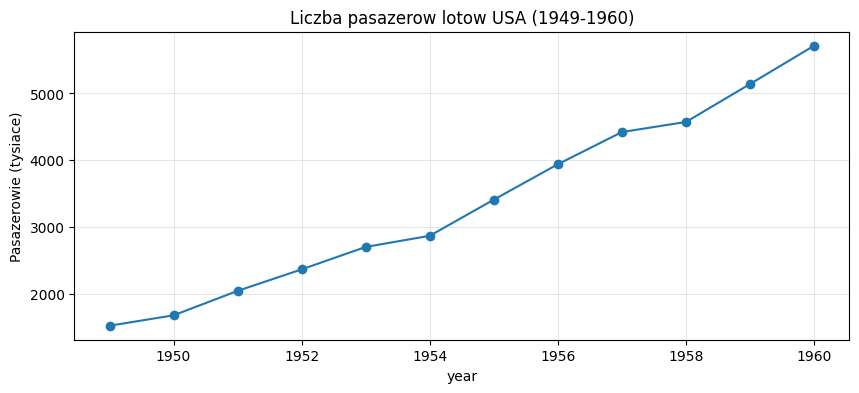

Trend: lotnictwo rosnie ~3x w 11 lat. Lata 50-te = boom.


In [9]:
rocznie.plot(kind="line", marker="o", figsize=(10, 4),
             title="Liczba pasazerow lotow USA (1949-1960)")
plt.ylabel("Pasazerowie (tysiace)")
plt.grid(alpha=0.3)
plt.show()

print("Trend: lotnictwo rosnie ~3x w 11 lat. Lata 50-te = boom.")

## 1.8. Pivot — przekształcenie long → wide

**Pivot** to jedna z najmocniejszych operacji w analizie danych. Pozwala zobaczyć dane "od drugiej strony".

In [10]:
# Rok x miesiac -- macierz pasazerow
pivot = flights.pivot(index="month", columns="year", values="passengers")
print(pivot)

year   1949  1950  1951  1952  1953  1954  1955  1956  1957  1958  1959  1960
month                                                                        
Jan     112   115   145   171   196   204   242   284   315   340   360   417
Feb     118   126   150   180   196   188   233   277   301   318   342   391
Mar     132   141   178   193   236   235   267   317   356   362   406   419
Apr     129   135   163   181   235   227   269   313   348   348   396   461
May     121   125   172   183   229   234   270   318   355   363   420   472
Jun     135   149   178   218   243   264   315   374   422   435   472   535
Jul     148   170   199   230   264   302   364   413   465   491   548   622
Aug     148   170   199   242   272   293   347   405   467   505   559   606
Sep     136   158   184   209   237   259   312   355   404   404   463   508
Oct     119   133   162   191   211   229   274   306   347   359   407   461
Nov     104   114   146   172   180   203   237   271   305   31

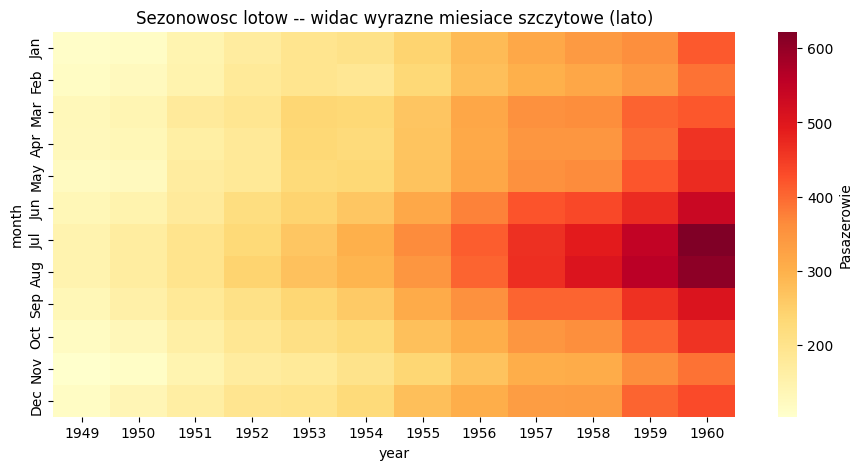

In [11]:
# Heatmap pokazuje sezonowosc -- klasyczny wykres!
plt.figure(figsize=(11, 5))
sns.heatmap(pivot, cmap="YlOrRd", annot=False, cbar_kws={'label': 'Pasazerowie'})
plt.title("Sezonowosc lotow -- widac wyrazne miesiace szczytowe (lato)")
plt.show()

## 1.9. Merge / Join — łączenie dwóch DataFrame'ów

W realnych projektach **rzadko** masz dane w jednej tabeli. Zwykle łączysz wiele.

In [12]:
# Druga tabela: miesiac -> kwartal
kwartaly = pd.DataFrame({
    "month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
              "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    "kwartal": [1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4]
})

polaczone = flights.merge(kwartaly, on="month", how="left")
print("Po polaczeniu z kwartalami:")
print(polaczone.head(8))

# Teraz mozna agregowac po kwartale
print("\nSrednia pasazerow per kwartal:")
print(polaczone.groupby("kwartal")["passengers"].mean().round(1))

Po polaczeniu z kwartalami:
   year month  passengers  kwartal
0  1949   Jan         112        1
1  1949   Feb         118        1
2  1949   Mar         132        1
3  1949   Apr         129        2
4  1949   May         121        2
5  1949   Jun         135        2
6  1949   Jul         148        3
7  1949   Aug         148        3

Srednia pasazerow per kwartal:
kwartal
1    249.0
2    283.5
3    334.9
4    253.8
Name: passengers, dtype: float64


## 1.10. Granice pandasa — kiedy umiera?

**pandas wczytuje WSZYSTKO do RAM.** To jego siła (szybkość) i słabość (limit).

Reguły kciuka 2026:

| Rozmiar danych | Pandas? | Co zrobić |
|----------------|---------|-----------|
| **< 1 GB** | Tak | Pandas + RAM. Wszystko OK. |
| **1-10 GB** | Pandas z chunkami albo Polars/DuckDB | `pd.read_csv(chunksize=...)`. Można jeszcze. |
| **10-100 GB** | NIE — Spark, Dask, Polars (lazy) | Tutaj zaczyna się Big Data. |
| **> 100 GB** | Spark / klaster | Pojedyncza maszyna już nie wystarczy. |

**Druga reguła:** pandas robi wszystko **na jednym wątku**. Twoje 16 rdzeni leży odłogiem. Spark od razu używa wszystkich rdzeni (i wielu maszyn).

**Co się dzieje, gdy pandas "umiera"?** Dwa scenariusze:
1. **MemoryError** — Python wpada w panikę, kernel pada
2. **Swap z dysku** — operacja trwa 10 minut zamiast 1 sekundy, bo system użyje dysku jako pamięci

---

# CZĘŚĆ 2 — Dlaczego pandas to za mało (problem skali)

## 2.1. Single machine vs Cluster

**Pandas** = jeden proces, jedna maszyna, jedna pamięć.

```
[Twoj laptop]
    |
    +-- pandas (1 wątek, 16GB RAM)
        |
        +-- jeden plik CSV: max ~10GB
```

**Spark** = wiele procesów, wiele maszyn, wiele pamięci.

```
[Cluster - 10 maszyn]
    |
    +-- Driver (koordynacja)
    +-- Worker 1 (executors)
    +-- Worker 2 (executors)
    +-- ...
    +-- Worker 10 (executors)
        |
        +-- razem: 160GB RAM, 80 rdzeni
        +-- jeden "plik" (rozproszony): TB+
```

## 2.2. Co Spark zmienia względem pandas?

| Cecha | pandas | PySpark |
|-------|--------|---------|
| Wykonanie | **eager** (natychmiastowe) | **lazy** (plan, potem wykonanie) |
| Skala | Pamięć jednego komputera | Pamięć całego klastra |
| Równoległość | Jeden wątek (głównie) | Setki wątków na wielu maszynach |
| Indeksowanie | Wiersze mają indeks | Brak indeksu (kolejność nieistotna) |
| Mutacja | `df['x'] = 1` modyfikuje DataFrame | Wszystko zwraca **nowy** DataFrame |
| API | Bardzo bogate, ad-hoc | Bardziej restrykcyjne, ale optymalizowane |
| Wyniki | Od razu w pamięci | Trzeba wywołać action (`show`, `collect`, `count`) |

## 2.3. Te same operacje — porównanie składni

| Operacja | pandas | PySpark |
|----------|--------|---------|
| Wczytanie CSV | `pd.read_csv("f.csv")` | `spark.read.csv("f.csv", header=True)` |
| Wybór kolumn | `df[["a", "b"]]` | `df.select("a", "b")` |
| Filtracja | `df[df.x > 5]` | `df.filter(df.x > 5)` |
| Nowa kolumna | `df["y"] = df.x * 2` | `df.withColumn("y", df.x * 2)` |
| groupBy | `df.groupby("a").sum()` | `df.groupBy("a").sum()` |
| Sortowanie | `df.sort_values("x")` | `df.orderBy("x")` |
| Limit | `df.head(10)` | `df.limit(10)` lub `df.show(10)` |
| Pierwsze N | `df.iloc[:10]` | `df.take(10)` lub `df.head(10)` |
| Liczba wierszy | `len(df)` | `df.count()` |
| Wszystkie dane | natywne | `df.collect()` lub `df.toPandas()` |

**Wniosek:** Jeśli znasz pandas — 70% PySparka już znasz. Różnice są w **kiedy** kod się wykonuje (eager vs lazy).

---

# CZĘŚĆ 3 — Architektura Spark (dla chętnych)

Ta część wyjaśnia, **dlaczego** Spark jest taki szybki i co dzieje się "pod maską". Nie musisz tego znać, żeby napisać działający kod, ale **musisz to znać**, żeby napisać szybki kod.

## 3.1. Driver, Executor, Cluster Manager

```
        TWOJ KOD                  WYNIK
          |                         ^
          v                         |
    +----------------+               |
    |     DRIVER     |---wynik-------+
    |  (Twoj laptop) |
    | * tworzy DAG   |
    | * koordynuje   |
    | * zbiera wynik |
    +----------------+
           |
           v zadania
    +----------------+
    | CLUSTER MANAGER|  (YARN / Kubernetes / Standalone)
    | * przydziela   |
    |   zasoby       |
    +----------------+
           |
    -------+-------+-------+
    |              |              |
    v              v              v
 [EXECUTOR]    [EXECUTOR]    [EXECUTOR]   <- pracuja na danych
  - taski        - taski        - taski       partycja po partycji
  - cache        - cache        - cache
  - dysk         - dysk         - dysk
```

**Driver** = mózg. Tworzy plan (DAG), dzieli pracę, zbiera wyniki.  
**Executor** = mięśnie. Wykonuje rzeczywiste obliczenia.  
**Cluster Manager** = HR. Przydziela maszyny do twojego zadania.

**Konsekwencja praktyczna:** gdy robisz `.toPandas()` lub `.collect()`, **wszystkie dane wracają na Driver**. Jeśli zbiór ma 100GB, a Driver ma 16GB RAM — kernel pada. Stąd zawsze najpierw `.limit(...)` lub agregacja.

## 3.2. DAG i Lazy Evaluation — magia Sparka

**Co robi pandas:**
```python
df = pd.read_csv("100gb.csv")  # <- wczytuje 100GB do RAM. Pada od razu.
```

**Co robi Spark:**
```python
df = spark.read.csv("100gb.csv")  # <- nic. Pamieta plan: "trzeba bedzie wczytac".
df = df.filter(df.year > 2020)    # <- nic. Plan: "...i odfiltrowac year>2020".
df = df.select("name", "year")    # <- nic. Plan: "...i wybrac 2 kolumny".
df.show(10)                       # <- DOPIERO TERAZ! Wykonuje optymalny plan.
```

**Dlaczego to ma sens?** Bo Catalyst Optimizer może zobaczyć **całość** i zoptymalizować:
- "Skoro wybiera tylko 2 kolumny, nie wczytuję 50."
- "Skoro filtruje year>2020, sprawdzę to przy czytaniu (predicate pushdown)."
- "Skoro to Parquet z partycjami po roku — przeczytaj tylko 5 z 50 katalogów."

**Rezultat:** Spark może być 100x szybszy od pandas na dużych danych. Albo 10x wolniejszy na małych — bo overhead orkiestracji.

### Transformations vs Actions

**Transformations** (leniwe — budują plan):
`select`, `filter`, `withColumn`, `groupBy`, `join`, `orderBy`, `agg`, ...

**Actions** (uruchamiają wykonanie):
`show()`, `count()`, `collect()`, `take(n)`, `toPandas()`, `write....`, `first()`

**Zasada:** dopóki nie wywołasz action, Spark nic nie robi. To **fundamentalna** różnica względem pandas.

## 3.3. Partycje — atomy Sparka

Spark dzieli każdy DataFrame na **partycje**. Każda partycja to kawałek danych, który **jeden task** przetwarza na **jednym executor**.

```
DataFrame (1 mld wierszy)
    |
    +-- Partycja 1 (100M wierszy)  -> Task 1 -> Executor A
    +-- Partycja 2 (100M wierszy)  -> Task 2 -> Executor A
    +-- Partycja 3 (100M wierszy)  -> Task 3 -> Executor B
    +-- ...
    +-- Partycja 10 (100M wierszy) -> Task 10 -> Executor E
```

**Reguła:** więcej partycji = więcej równoległości. Ale za dużo małych partycji = overhead.

**Typowo:** 2-4 partycje na rdzeń. Spark sam wybiera (200 jest domyślne dla shuffle), ale możesz wymusić:
- `df.repartition(100)` — full shuffle, dokładnie 100 partycji
- `df.coalesce(10)` — bez shuffle, łączy partycje. Tylko **mniejsza** liczba.

**Praktyka:** używaj `repartition` po `read`, `coalesce` przed `write`.

## 3.4. Shuffle — wróg numer jeden

**Shuffle** = przeniesienie danych między partycjami (a często między maszynami).

Kiedy występuje?
- `groupBy` — dane tej samej grupy muszą trafić na ten sam executor
- `join` — pasujące klucze muszą się spotkać
- `orderBy` — globalne sortowanie wymaga przegrupowania
- `repartition` — z definicji

**Dlaczego boli?** Bo to **sieć i dysk**. Najwolniejsze rzeczy w komputerze. Jeden shuffle 1TB może trwać godziny.

**Jak unikać?**
1. **Broadcast join** — jeśli jedna tabela jest mała (<10MB), wyślij ją do każdego executora. Zero shuffle.
2. **Filter wcześnie** — najpierw filter, potem groupBy. Mniej danych = mniejszy shuffle.
3. **Select tylko potrzebnych kolumn** — to samo.
4. **Partycjonowane Parquet** — `df.write.partitionBy("year").parquet(...)`. Później filtrowanie po `year` nie wymaga skanowania.

## 3.5. Catalyst Optimizer

Catalyst to optymalizator zapytań Sparka. Działa w 4 fazach:

1. **Analysis** — sprawdza, czy kolumny istnieją, typy się zgadzają
2. **Logical Optimization** — przepisuje plan logiczny (np. "filter przed join")
3. **Physical Planning** — wybiera fizyczny plan (np. broadcast vs shuffle join)
4. **Code Generation** — generuje skompilowany Java bytecode

**Twoja rola:** dawaj Catalystowi **proste, czyste zapytania**. UDF-y są szkodliwe — Catalyst ich nie rozumie, więc nie może zoptymalizować.

---

# CZĘŚĆ 4 — PySpark w akcji (wszystkie operacje z prezentacji)

Czas na PySpark. Wczytamy ten sam `flights` dataset (żeby było widać porównanie z pandasem) i przejdziemy przez **każdy temat z prezentacji**.

## 4.1. Setup Sparka

In [ ]:
# Setup Sparka -- robust dla macOS / Linux
import os
import sys
import shutil

# 1. JAVA_HOME -- wykryj automatycznie
if "JAVA_HOME" not in os.environ:
    for candidate in [
        "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home",  # macOS Apple Silicon
        "/opt/homebrew/opt/openjdk/libexec/openjdk.jdk/Contents/Home",
        "/usr/local/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home",     # macOS Intel
        "/usr/lib/jvm/java-17-openjdk-amd64",                              # Linux Debian/Ubuntu
    ]:
        if os.path.exists(candidate):
            os.environ["JAVA_HOME"] = candidate
            print(f"JAVA_HOME -> {candidate}")
            break
    else:
        print("UWAGA: JAVA_HOME nie ustawiony i nie znaleziono Javy. Ustaw recznie!")

# 2. PYSPARK_PYTHON -- WAZNE! Spark workers musza uzywac tego samego Pythona co kernel.
#    Bez tego workers moga sprobowac uzyc systemowego Python 3.9 i pasc z dziwnymi bledami
#    ("EOFException from pyspark.daemon", "unsupported operand type(s) for |: 'type' and 'type'", itp.)
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
print(f"PYSPARK_PYTHON -> {sys.executable}")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import Window

spark = SparkSession.builder \
    .appName("Lab5 Deep Dive") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"\nSpark: {spark.version}")
print(f"App ID: {spark.sparkContext.applicationId}")

## 4.2. Tworzenie DataFrame — 5 sposobów (slide z prezentacji)

In [ ]:
# Sposob 1: z pandas DataFrame (najwygodniej dla malych danych)
df_flights = spark.createDataFrame(flights)
print("Sposob 1 -- z pandas:")
df_flights.show(5)
df_flights.printSchema()

In [ ]:
# Sposob 2: z listy slownikow
df_dict = spark.createDataFrame([
    {"name": "Anna", "age": 25},
    {"name": "Jan", "age": 30}
])
df_dict.show()

# Sposob 3: z listy krotek + schemat
from pyspark.sql.types import StructType, StructField, StringType, IntegerType
schema = StructType([
    StructField("name", StringType(), True),
    StructField("age", IntegerType(), True)
])
df_tup = spark.createDataFrame([("Anna", 25), ("Jan", 30)], schema)
df_tup.show()

# Sposob 4: z RDD
rdd = spark.sparkContext.parallelize([("Anna", 25), ("Jan", 30)])
df_rdd = rdd.toDF(["name", "age"])
df_rdd.show()

# Sposob 5: z pliku (CSV/JSON/Parquet)
# df = spark.read.csv("plik.csv", header=True, inferSchema=True)

## 4.3. Schema explicit — best practice

In [ ]:
# Tlumaczymy 'month' (kategoria) na string -- bo pandas robi go category
df_flights = df_flights.withColumn("month", F.col("month").cast("string"))

# Sprawdz schema
df_flights.printSchema()
print("\nLiczba wierszy:", df_flights.count())

## 4.4. select + alias + F.col + F.lit

In [ ]:
# Wybor kolumn z aliasem i wyrazeniem
df_flights.select(
    F.col("year").alias("rok"),
    F.col("month").alias("miesiac"),
    F.col("passengers"),
    (F.col("passengers") * F.lit(1000)).alias("pasazerowie_faktycznie")
).show(5)

## 4.5. withColumn — tworzenie nowych kolumn

In [ ]:
# Dodaj kolumny: dekada + czy_letni_miesiac
df2 = df_flights \
    .withColumn("dekada", (F.col("year") / 10).cast("int") * 10) \
    .withColumn("summer", F.col("month").isin("Jun", "Jul", "Aug"))

df2.show(8)

## 4.6. when / otherwise — warunkowe wartości

In [ ]:
# Klasyfikacja ruchu jako 'high', 'medium', 'low'
df3 = df_flights.withColumn(
    "poziom_ruchu",
    F.when(F.col("passengers") > 400, F.lit("wysoki"))
     .when(F.col("passengers") > 200, F.lit("sredni"))
     .otherwise(F.lit("niski"))
)

df3.groupBy("poziom_ruchu").count().show()

## 4.7. groupBy + agg — agregacje

In [ ]:
# Wiele agregacji naraz
df_flights.groupBy("year").agg(
    F.sum("passengers").alias("suma"),
    F.round(F.avg("passengers"), 1).alias("srednia"),
    F.min("passengers").alias("min"),
    F.max("passengers").alias("max"),
    F.count("*").alias("liczba_miesiecy")
).orderBy("year").show()

## 4.8. Window operations — najwyżej cenione w analizie

**Window functions** = agregacje bez zmiany liczby wierszy. Dodajesz informację "obok" zamiast grupować.

Klasyczne pytania:
- *"Który miesiąc był szczytowy w każdym roku?"*
- *"Jakie jest skumulowane sum od początku roku?"*
- *"Jak każdy miesiąc plasuje się w rankingu?"*

In [ ]:
# Ranking miesiecy w kazdym roku
okno_roku = Window.partitionBy("year").orderBy(F.col("passengers").desc())

ranked = df_flights.withColumn("ranking", F.row_number().over(okno_roku))

# Top 1 w kazdym roku
top_miesiac_w_roku = ranked.filter(F.col("ranking") == 1)
print("Najbardziej ruchliwy miesiac w kazdym roku:")
top_miesiac_w_roku.orderBy("year").show()

# Skumulowana suma od poczatku roku
okno_skum = Window.partitionBy("year").orderBy("month").rowsBetween(Window.unboundedPreceding, 0)
skum = df_flights.withColumn("skumulowane", F.sum("passengers").over(okno_skum))
print("\nSkumulowane sumy w roku 1960:")
skum.filter(F.col("year") == 1960).orderBy("month").show(12)

## 4.9. Pivot — to samo co w pandasie

In [ ]:
# Pivot: month x year
df_flights.groupBy("month").pivot("year").sum("passengers").show(12)

## 4.10. Join — łączenie tabel

In [ ]:
# Tabela z kwartalami
df_kwartaly = spark.createDataFrame([
    ("Jan", 1), ("Feb", 1), ("Mar", 1),
    ("Apr", 2), ("May", 2), ("Jun", 2),
    ("Jul", 3), ("Aug", 3), ("Sep", 3),
    ("Oct", 4), ("Nov", 4), ("Dec", 4)
], schema=["month", "kwartal"])

# Inner join
z_kwartalem = df_flights.join(df_kwartaly, on="month", how="left")

z_kwartalem.groupBy("year", "kwartal") \
    .agg(F.sum("passengers").alias("sum_pas")) \
    .orderBy("year", "kwartal") \
    .show(10)

## 4.11. Spark SQL — alternatywne API

In [ ]:
# Rejestruj tablice jako widok
df_flights.createOrReplaceTempView("flights")

# Pelne SQL!
spark.sql("""
    SELECT year,
           SUM(passengers) AS total,
           ROUND(AVG(passengers), 1) AS srednia
    FROM flights
    GROUP BY year
    ORDER BY year
""").show()

## 4.12. UDF — własne funkcje (i dlaczego ostrożnie)

In [ ]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

@udf(StringType())
def klasyfikuj_miesiac(m):
    if m in ("Dec", "Jan", "Feb"):
        return "zima"
    elif m in ("Mar", "Apr", "May"):
        return "wiosna"
    elif m in ("Jun", "Jul", "Aug"):
        return "lato"
    return "jesien"

df_flights.withColumn("pora_roku", klasyfikuj_miesiac("month")) \
    .groupBy("pora_roku") \
    .agg(F.round(F.avg("passengers"), 1).alias("srednia_pasazerow")) \
    .orderBy("srednia_pasazerow", ascending=False) \
    .show()

**Lekcja o UDF-ach:** Powyższe można było zrobić bez UDF, przez `F.when().when()...`. Wtedy Catalyst by zoptymalizował. UDF-y są wolne, bo Spark musi serializować dane do Pythona dla każdego wiersza.

**Zasada:** użyj UDF dopiero, gdy `F.when`, `F.regexp_replace`, `F.split` itp. nie wystarczą.

## 4.13. explain() — co naprawdę robi Spark

In [ ]:
# Plan zapytania -- widzimy, co Catalyst zoptymalizowal
agregacja = df_flights \
    .filter(F.col("year") >= 1955) \
    .select("year", "passengers") \
    .groupBy("year") \
    .sum("passengers")

agregacja.explain(mode="formatted")

**Co czytać w `explain()`:**
- `*` przy operacjach = code generation (szybkie!)
- `Exchange` = shuffle (drogie!) — staraj się minimalizować
- `Filter` na samym dole = predicate pushdown
- `Project` = które kolumny faktycznie czytane

---

# CZĘŚĆ 5 — At Scale Demo (dla chętnych)

Czas zobaczyć, co Spark daje na **dużych** danych. Wygenerujemy synthetic dataset 1M rekordów (symulujący transakcje e-commerce) i pokażemy:
- Jak pandas się dusi, a Spark nie
- cache() vs persist()
- broadcast join
- partycjonowany Parquet

In [ ]:
# Synthetic dataset: 1 milion transakcji e-commerce
import time
import random

N = 1_000_000
print(f"Generuje {N:,} synthetic transakcji...")

t0 = time.time()
df_big = spark.range(N).select(
    F.col("id").alias("transaction_id"),
    F.lit("2024-01-01").cast("date").alias("date_base"),  # baza, dodamy losowy offset
    (F.col("id") % 1000).alias("customer_id"),
    (F.col("id") % 50).alias("product_id"),
    (F.rand(seed=42) * 1000).alias("amount"),
    F.when(F.col("id") % 10 == 0, F.lit("premium")).otherwise(F.lit("standard")).alias("tier")
)
df_big = df_big.withColumn("date", F.date_add(F.col("date_base"), (F.rand(seed=1) * 365).cast("int"))) \
    .drop("date_base")
print(f"Definicja gotowa w {time.time()-t0:.2f}s (lazy -- jeszcze nic nie policzono)")

# Sprawdzamy schema
df_big.printSchema()

# Pierwsze 5 wierszy (TERAZ Spark cos robi)
t0 = time.time()
df_big.show(5)
print(f"show(5) w {time.time()-t0:.2f}s")

In [ ]:
# Agregacja na 1M rekordow
t0 = time.time()
wynik = df_big.groupBy("tier").agg(
    F.count("*").alias("liczba"),
    F.round(F.avg("amount"), 2).alias("srednia_kwota"),
    F.round(F.sum("amount"), 0).alias("suma")
)
wynik.show()
print(f"Agregacja 1M rekordow: {time.time()-t0:.2f}s")

## 5.1. cache() — gdy ten sam DataFrame używasz wielokrotnie

Spark domyślnie **przelicza wszystko od zera** przy każdej action. Jeśli używasz tego samego DataFrame 5x, Spark go wczyta i przetworzy 5 razy.

**Rozwiązanie:** `cache()`. Spark zapisze wynik w pamięci po **pierwszym** wykonaniu.

In [ ]:
# BEZ cache -- liczy 3 razy
df_cleaned = df_big.filter(F.col("amount") > 100)

t0 = time.time()
c1 = df_cleaned.count()
t1 = time.time()
c2 = df_cleaned.filter(F.col("tier") == "premium").count()
t2 = time.time()
c3 = df_cleaned.groupBy("tier").count().collect()
t3 = time.time()

print(f"BEZ cache:")
print(f"  count():        {t1-t0:.2f}s")
print(f"  filter+count(): {t2-t1:.2f}s")
print(f"  groupBy:        {t3-t2:.2f}s")
print(f"  RAZEM:          {t3-t0:.2f}s\n")

# Z cache
df_cleaned_cached = df_big.filter(F.col("amount") > 100).cache()
df_cleaned_cached.count()  # materializacja

t0 = time.time()
c1 = df_cleaned_cached.count()
t1 = time.time()
c2 = df_cleaned_cached.filter(F.col("tier") == "premium").count()
t2 = time.time()
c3 = df_cleaned_cached.groupBy("tier").count().collect()
t3 = time.time()

print(f"Z cache (po materializacji):")
print(f"  count():        {t1-t0:.2f}s")
print(f"  filter+count(): {t2-t1:.2f}s")
print(f"  groupBy:        {t3-t2:.2f}s")
print(f"  RAZEM:          {t3-t0:.2f}s")

df_cleaned_cached.unpersist()  # zwolnij pamiec

## 5.2. broadcast join — gdy jedna tabela jest mała

In [ ]:
# Mala tabela produktow (50 wierszy)
produkty = spark.createDataFrame([
    (i, f"Produkt {i}", "Elektronika" if i < 25 else "Ubrania")
    for i in range(50)
], ["product_id", "nazwa", "kategoria"])

# Bez broadcast -- shuffle join (Spark wybierze sam jesli mala -- ale wymusmy)
from pyspark.sql.functions import broadcast

# Z broadcast: mala tabela jest wyslana do KAZDEGO executora
wynik = df_big.join(broadcast(produkty), on="product_id")
wynik.groupBy("kategoria").agg(
    F.count("*").alias("transakcje"),
    F.round(F.sum("amount"), 0).alias("przychod")
).show()

# Sprawdz w explain() -- powinno byc "BroadcastHashJoin" zamiast "SortMergeJoin"
wynik.explain()

## 5.3. Zapis do partycjonowanego Parquet

**Parquet** = kolumnowy format binarny. ~10x mniejszy od CSV, ~100x szybszy do czytania.

**Partycjonowanie** = fizyczny podział pliku na podkatalogi. Dzięki temu `WHERE year=2024` czyta tylko jeden katalog.

In [ ]:
import shutil
import os

# Wyciagniemy rok z date i podzielmy po nim
df_to_save = df_big.withColumn("year", F.year("date"))

output_dir = "transactions_parquet"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

t0 = time.time()
df_to_save.write.mode("overwrite").partitionBy("year").parquet(output_dir)
print(f"Zapisano partycjonowany Parquet w {time.time()-t0:.2f}s")

# Sprawdz strukture katalogow
for path in sorted(os.listdir(output_dir))[:10]:
    print(f"  {path}")

# Teraz odczyt + filter po roku -- predicate pushdown
t0 = time.time()
tylko_2024 = spark.read.parquet(output_dir).filter(F.col("year") == 2024).count()
print(f"\nOdczyt + filter year=2024: {time.time()-t0:.2f}s, wierszy: {tylko_2024:,}")

---

# CZĘŚĆ 6 — Kiedy NIE używać Sparka

Spark **nie jest złotym młotkiem.** Dla małych danych jest po prostu **wolniejszy** niż pandas, bo płacisz overhead JVM + orchestracji.

## 6.1. Drzewo decyzyjne

```
                 Ile masz danych?
                       |
        +--------------+---------------+
        |              |               |
       <1GB         1-100GB           >100GB
        |              |               |
      pandas    +------+------+      Spark
                |             |    (must)
         Czy szybki     Czy dane sa
         eksperyment?   na klastrze?
                |             |
             pandas        Spark
          (Polars/DuckDB    (perfect)
          alt.)
```

## 6.2. Alternatywy 2026

| Narzędzie | Kiedy | Plusy | Minusy |
|-----------|-------|-------|--------|
| **pandas** | <1GB, eksploracja | Bogate API, szybki dla małych | Single-thread, RAM-bound |
| **Polars** | 1-100GB, lokalnie | 10x szybszy niż pandas, multi-core | Inne API (Expr-based) |
| **DuckDB** | 1-100GB, analytics | SQL na lokalnych plikach | Lokalny, nie rozproszony |
| **Dask** | 10-500GB | API jak pandas, rozproszone | Trudniejszy debug niż Spark |
| **PySpark** | 100GB+, klaster, prod | Industry standard, MLlib | Overhead JVM, JOIN-heavy ops |
| **Ray** | ML at scale | Doskonały dla DL | Mniej dojrzały niż Spark |

## 6.3. Reguły kciuka

1. **Jeśli mieści się w RAM** — pandas/Polars/DuckDB. Spark to overkill.
2. **Jeśli przetwarzasz w produkcji codziennie** — Spark. Bo jest sprawdzony i ma ekosystem (Airflow, Databricks, EMR).
3. **Jeśli to pipeline ML** — Spark (MLlib) lub Ray.
4. **Jeśli to ad-hoc analytics** — DuckDB. Najprostsze dziś.
5. **Jeśli twój dataset rośnie 10x rocznie** — od razu Spark. Migracja później = ból.

## 6.4. Co MUSISZ wiedzieć z PySparka

Lista "absolute minimum" — to musisz znać po tym labie:

- [x] `SparkSession.builder.appName(...).getOrCreate()`
- [x] `spark.read.csv` / `.parquet` / `.json`
- [x] `df.select`, `df.filter`, `df.withColumn`, `df.groupBy.agg`
- [x] `F.col`, `F.lit`, `F.when().otherwise()`
- [x] Różnica **transformation** vs **action**
- [x] Dlaczego `.collect()` jest niebezpieczne dla dużych danych
- [x] `df.cache()` przed wielokrotnym użyciem
- [x] `df.explain()` żeby zobaczyć plan
- [x] Spark SQL przez `createOrReplaceTempView`

Reszta — przyjdzie z praktyką.

In [ ]:
# Zamknij sesje Sparka
spark.stop()
print("SparkSession zakonczona. Koniec deep dive.")

---

## Dalej?

Jeśli przeszedłeś przez to wszystko — gratulacje. To więcej, niż 90% programistów w branży wie o PySparku.

**Co dalej?**

1. **MLlib** — uczenie maszynowe w Sparku. Klasyfikacja, regresja, clustering, recommenders.
2. **Spark Streaming** — przetwarzanie strumieni (Kafka → analiza w locie).
3. **Databricks** — komercyjna platforma na Sparku. Wszystkie firmy używają. Darmowy Community Edition.
4. **Delta Lake** — Parquet + transakcje ACID + time-travel. Standard w Big Data 2026.
5. **Apache Iceberg** — alternatywa dla Delta. Open table format.

**Książki:**
- *Learning PySpark* — Holden Karau (klasyk)
- *Spark: The Definitive Guide* — Bill Chambers (referencja)
- *Designing Data-Intensive Applications* — Martin Kleppmann (nie o Sparku, ale o tym jak myśleć o danych w skali)

**Pamiętaj:** PySpark to narzędzie. Najważniejsze umiejętności to **myślenie o danych** — co jest tabelą, co kluczem, jak unikać shuffle, jak partycjonować. Składnia przyjdzie szybko.